# Демо: конструктор дискурс-графа (фаза 1)

Переключение комбинаций методов через `ConstructorConfig` или CLI `run_constructor.py`.

In [5]:
from discourse_graph.config import ConstructorConfig
from discourse_graph.pipeline import DiscourseGraphConstructor

cfg = ConstructorConfig(
    vertex_methods=["ner", "yake", "tfidf", "textrank", "paraphrase_cluster"],
    edge_methods=["cooccurrence", "anaphora", "rhetorical", "emotional", "perplexity"],
    output_dir="data/graphs/naukogrady/constructor",
    summarize_vertices=False,  # True — саморайз через cointegrated/rubert-tiny2
    hf_model="cointegrated/rubert-tiny2",
)

constructor = DiscourseGraphConstructor(cfg)
result = constructor.run("data/raw/naukogrady/documents.json")
result["meta"]

Готово: 211 узлов, 216 рёбер -> data/graphs/naukogrady/constructor


{'n_docs': 221,
 'vertex_methods': ['ner', 'yake', 'tfidf', 'textrank', 'paraphrase_cluster'],
 'edge_methods': ['cooccurrence',
  'anaphora',
  'rhetorical',
  'emotional',
  'perplexity'],
 'nodes': 211,
 'edges': 216}

## Визуализация результата

Граф из `result["graph"]`: сеть топ-узлов, сообщества, сравнение с baseline.

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from discourse_graph.visualize import (
    show_communities,
    show_degree_distribution,
    show_graph_network,
    show_graphs_comparison,
)

G = result["graph"]
G_base = result.get("baseline")

print(f"Дискурс-граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")
print(f"Компонент связности: {nx.number_connected_components(G)}")

Дискурс-граф: 211 узлов, 216 рёбер
Компонент связности: 63


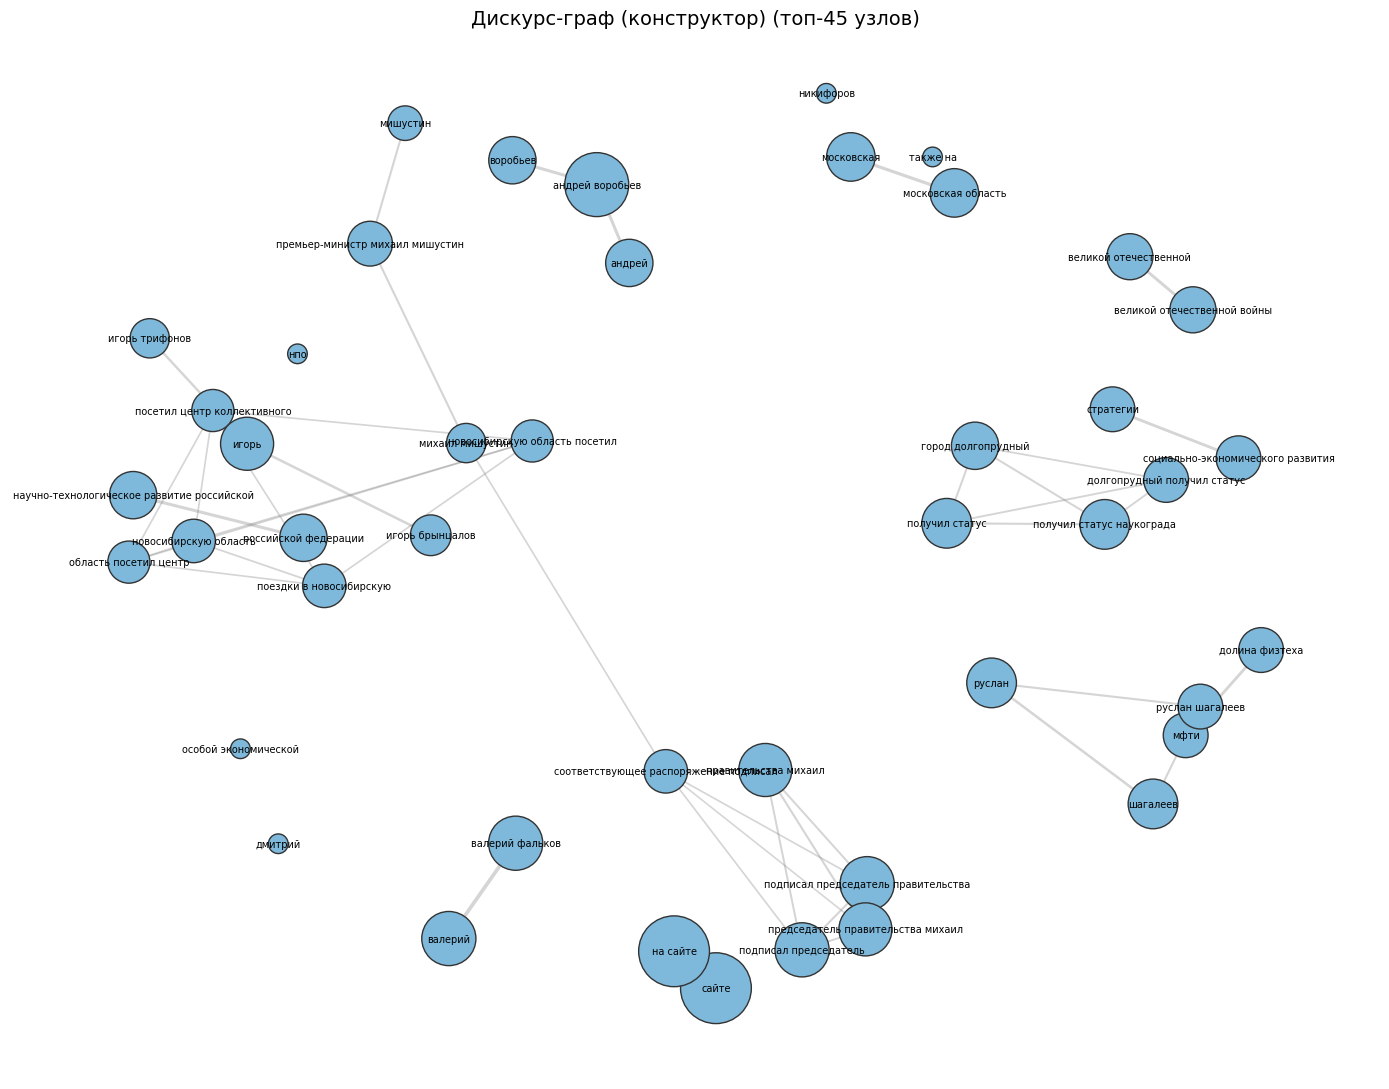

In [7]:
show_graph_network(G, title="Дискурс-граф (конструктор)", max_nodes=45)
plt.show()

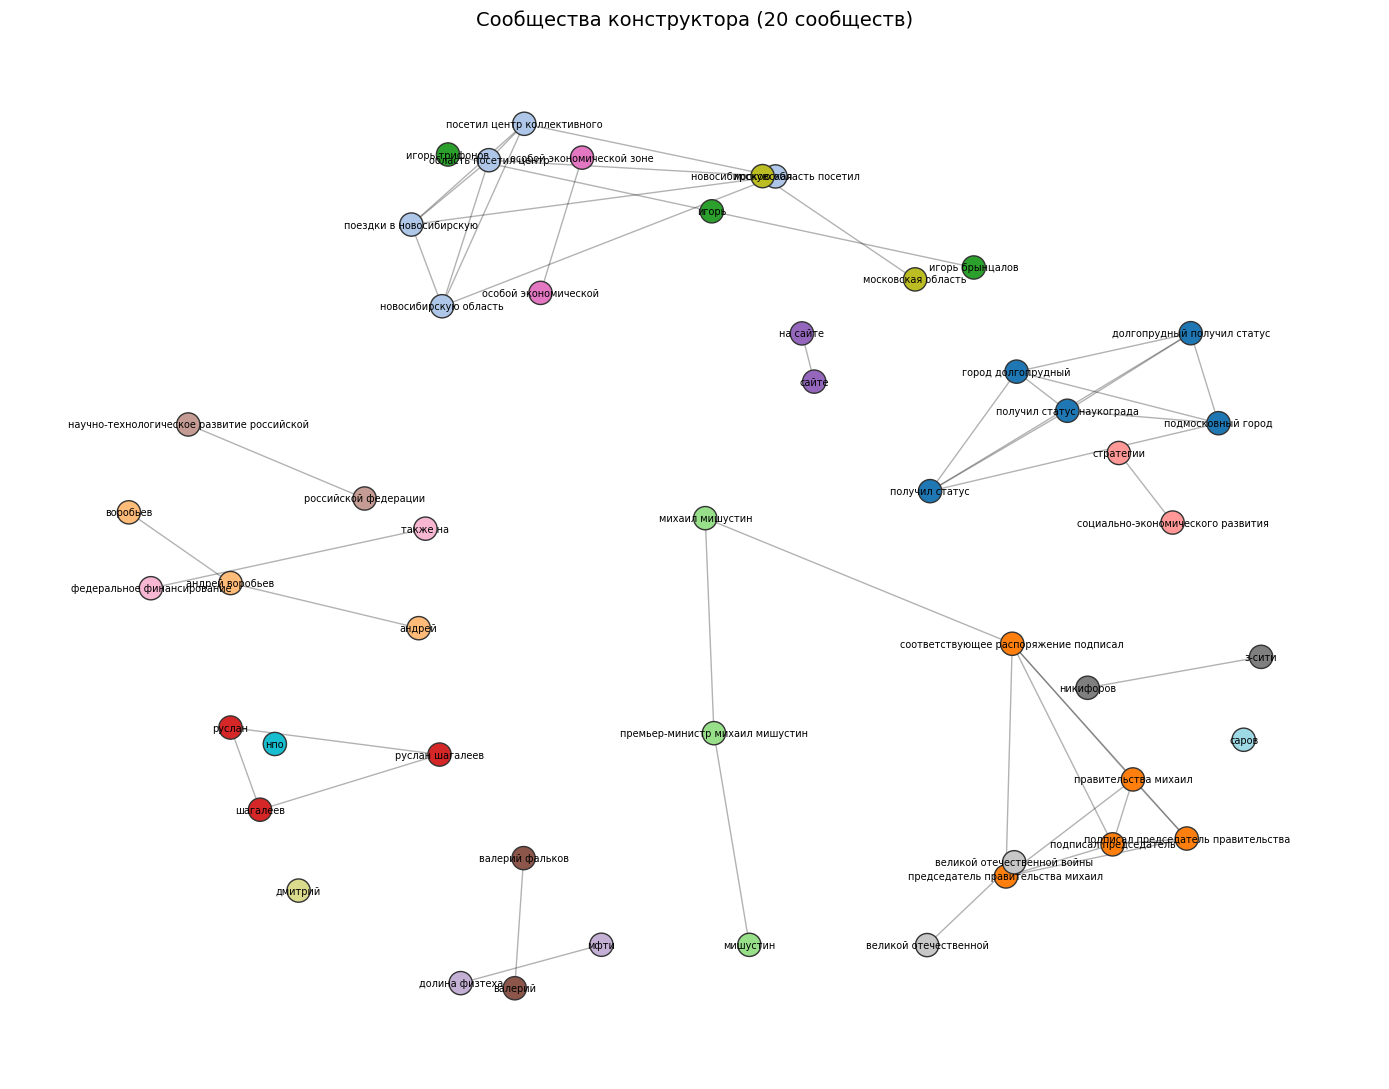

In [8]:
show_communities(G, title="Сообщества конструктора", max_nodes=50)
plt.show()

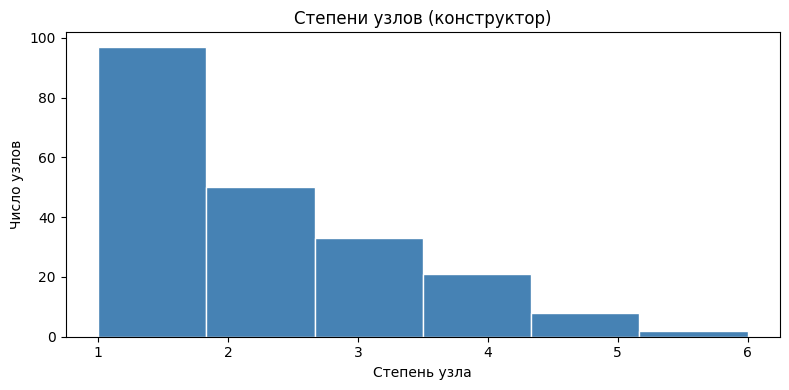

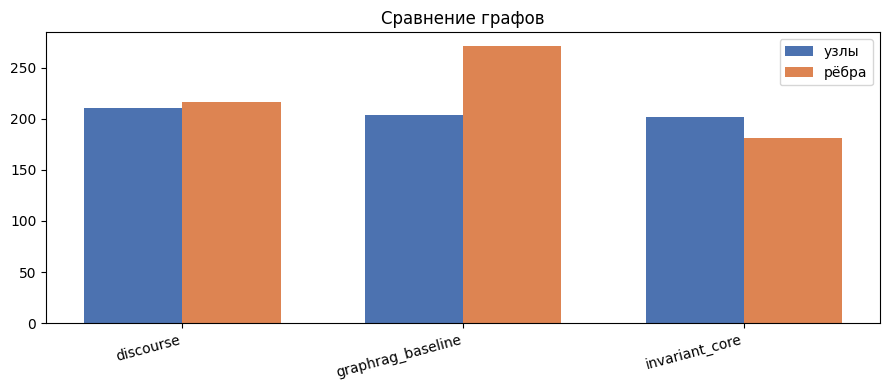

In [9]:
show_degree_distribution(G, title="Степени узлов (конструктор)")
plt.show()

if G_base is not None:
    graphs = {"discourse": G, "graphrag_baseline": G_base}
    if "stress" in result and result["stress"].get("graph_core") is not None:
        graphs["invariant_core"] = result["stress"]["graph_core"]
    show_graphs_comparison(graphs)
    plt.show()

In [10]:
# Топ рёбер: вес и surprisal («жареные» связи)
edge_rows = [
    {"source": u, "target": v, **d}
    for u, v, d in G.edges(data=True)
]
edges_df = pd.DataFrame(edge_rows)
if "surprisal" in edges_df.columns:
    display(edges_df.nlargest(10, "surprisal")[["source", "target", "weight", "surprisal", "methods"]])
else:
    display(edges_df.nlargest(10, "weight")[["source", "target", "weight", "methods"]])

,source,target,weight,surprisal,methods
1,ссср,ниизм,2,17.5961,"[anaphora, cooccurrence, perplexity]"
3,саров,нижегородской области,2,17.5961,"[cooccurrence, perplexity]"
6,новосибирске,рабочая встреча полномочного,2,17.5961,"[cooccurrence, perplexity]"
7,академии наук,ниизм,2,17.5961,"[anaphora, cooccurrence, perplexity]"
8,академии наук,министерства науки,2,17.5961,"[cooccurrence, emotional, perplexity]"
9,черноголовке,институт физики,2,17.5961,"[cooccurrence, emotional, perplexity]"
10,королев,королевской больницы,4,17.5961,"[cooccurrence, emotional, perplexity]"
14,тасс,рудольф дик,2,17.5961,"[cooccurrence, perplexity]"
15,тасс,наукограда николай красников,2,17.5961,"[cooccurrence, emotional, perplexity]"
17,страх,юлия коротун,3,17.5961,"[anaphora, cooccurrence, perplexity]"


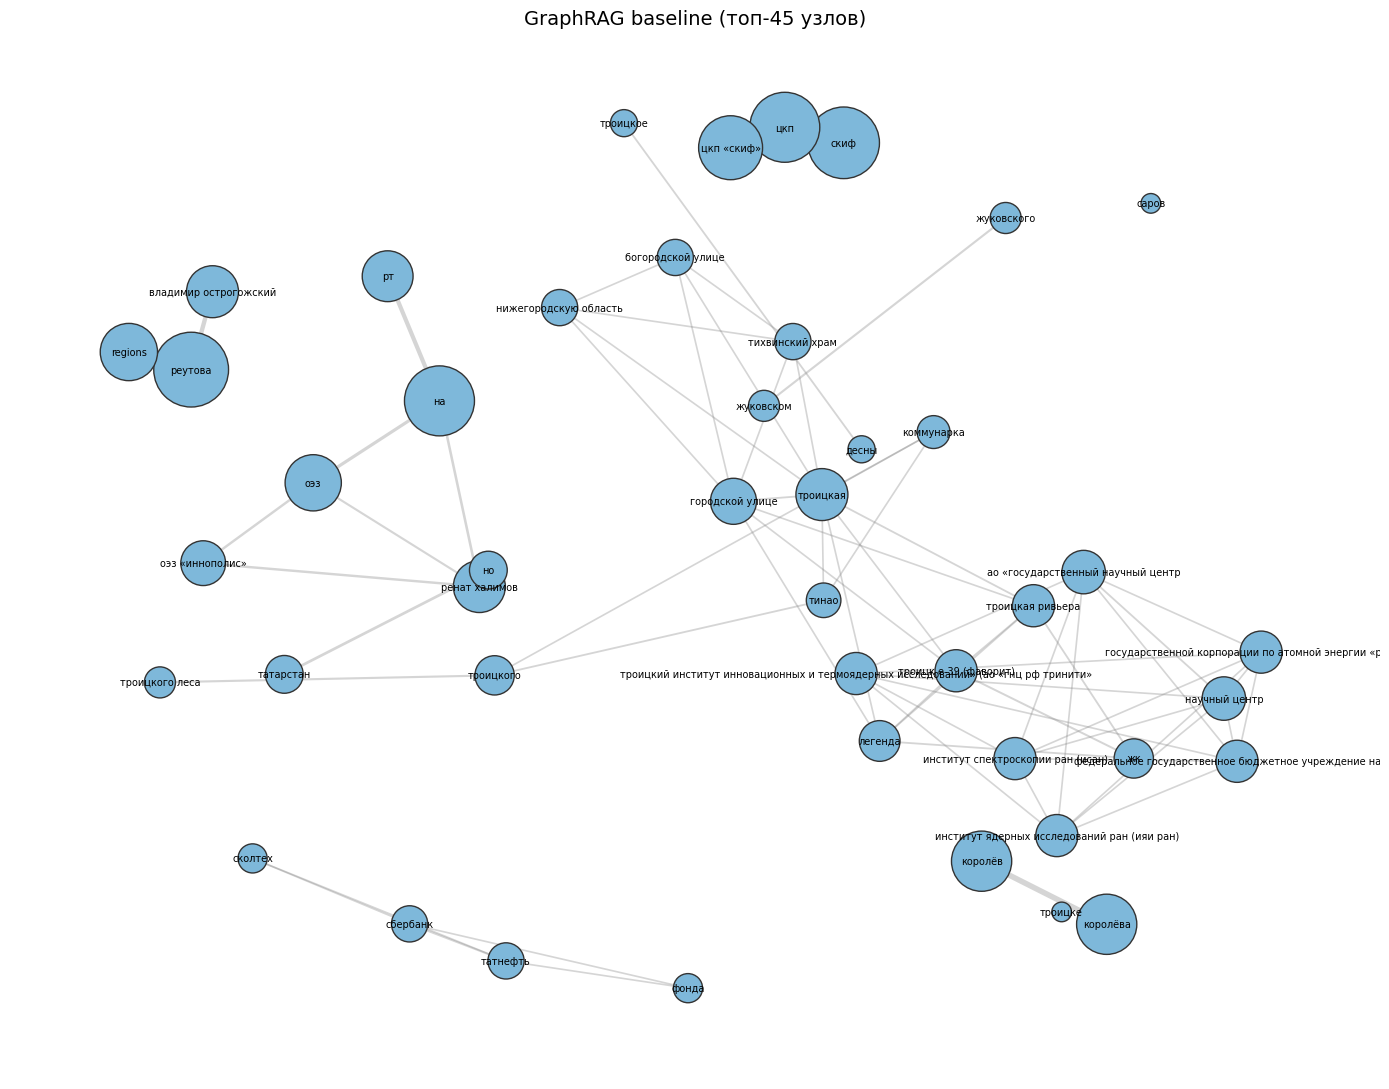

In [11]:
if G_base is not None:
    show_graph_network(G_base, title="GraphRAG baseline", max_nodes=45)
    plt.show()

In [12]:
# Пример: только co-occurrence + NER
cfg_min = ConstructorConfig(
    vertex_methods=["ner", "yake"],
    edge_methods=["cooccurrence"],
    output_dir="data/graphs/naukogrady/constructor_minimal",
)
DiscourseGraphConstructor(cfg_min).run(
    "data/raw/naukogrady/documents.json",
    run_stress=False,
)

Готово: 252 узлов, 359 рёбер -> data/graphs/naukogrady/constructor_minimal


{'graph': <networkx.classes.graph.Graph at 0x12c114320>,
 'meta': {'n_docs': 221,
  'vertex_methods': ['ner', 'yake'],
  'edge_methods': ['cooccurrence'],
  'nodes': 252,
  'edges': 359},
 'baseline': <networkx.classes.graph.Graph at 0x12434c050>}